# Lab 1: OV7675 Image Viewer


Takes the hexadecimal output of the Camera Test from the Serial Monitor and converts and displays it as an image.

In [1]:
# Import the needed libraries
from matplotlib import pyplot as plt
import numpy as np
import struct

Update the following variable with the output of your Serial Monitor.

In [2]:
# Copy the output of the Serial Monitor to the variable below
HEXADECIMAL_BYTES = [
0x3094, 0x3094, 0x3094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5294, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x708C, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x2F8C, 0xF84, 0xEF83, 0xCD83, 0xAD7B, 0xAD73, 0x8E73, 0x4E6B, 0x6C6B, 0x6C63, 0x8E6B, 0xE810, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0x98C, 0xCE7B, 0xD84, 0x2F8C, 0x308C, 0x4F94, 0x708C, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0x3094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x508C, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0xF8C, 0xF84, 0xF84, 0xCD83, 0xAD7B, 0x8E73, 0x8E73, 0x6E6B, 0x6C6B, 0x6C63, 0x6E63, 0xC710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x12A, 0xB8C, 0xCD7B, 0xD84, 0x2F8C, 0x308C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x909C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0x3094, 0x3094, 0x3094, 0x3094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7294, 0x5294, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x4F8C, 0x2F84, 0xF8C, 0xF8C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0xCD7B, 0x8E73, 0x6E6B, 0x6C6B, 0x8C6B, 0xAE6B, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x6132, 0x2C8C, 0xCD7B, 0xED83, 0x2F8C, 0x308C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x7294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF29C, 0xF29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0x3094, 0x3094, 0x3094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xEF83, 0xED7B, 0xCD7B, 0xAD73, 0x8E73, 0x6C6B, 0x4C6B, 0x4C63, 0x4D5B, 0x8510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA13A, 0xEE83, 0xCE7B, 0xCD83, 0x2F8C, 0x308C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x909C, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0x929C, 0xB19C, 0xB19C, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0x108C, 0xF8C, 0xF84, 0xEF83, 0xED7B, 0xCD7B, 0xAE73, 0x8E73, 0x6C6B, 0x6C6B, 0x6C6B, 0xD5B, 0x8510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE142, 0x4E8C, 0xED83, 0xED83, 0x2F8C, 0x4F8C, 0x4F94, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x929C, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xD29C, 0xB19C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xB29C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0x929C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x308C, 0x108C, 0xF8C, 0xF84, 0xEF83, 0xAD7B, 0xAD7B, 0xAD73, 0x6E73, 0x4C6B, 0x4C73, 0x4E6B, 0xAD51, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x2149, 0x2E84, 0xD84, 0xF84, 0x2F8C, 0x2F8C, 0x4F94, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0x919C, 0xB29C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xB19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7294, 0x9094, 0x7294, 0x7094, 0x5094, 0x5094, 0x5094, 0x5294, 0x5094, 0x5294, 0x5094, 0x5094, 0x5094, 0x3094, 0x3094, 0x3094, 0x508C, 0x308C, 0x308C, 0x108C, 0xF8C, 0xEF83, 0xF84, 0xAD7B, 0xAD7B, 0x8E73, 0x6E73, 0x4C6B, 0x6C6B, 0x6C73, 0xAE51, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA459, 0xED7B, 0xED7B, 0xF84, 0xF8C, 0x2F8C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xF1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5294, 0x5294, 0x7094, 0x7094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x3094, 0x3094, 0x308C, 0x108C, 0x308C, 0x108C, 0xF84, 0xEF83, 0xEF83, 0xCD7B, 0xAD7B, 0x8E73, 0x6E73, 0x4C6B, 0x4C6B, 0x8C6B, 0x6D49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x8359, 0xAF7B, 0xED83, 0xF8C, 0x4F8C, 0x2F8C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xD19C, 0xD29C, 0xF29C, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x3094, 0x508C, 0x308C, 0x308C, 0x308C, 0x108C, 0xEF83, 0xEF83, 0xEF83, 0xCD7B, 0xAD7B, 0x8D73, 0x6E73, 0x4E6B, 0x4C6B, 0xAC73, 0x6C49, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x463, 0xAD7B, 0xED83, 0xF84, 0x2F8C, 0x4F8C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xCF83, 0xAD7B, 0xAD7B, 0x8E7B, 0x6E73, 0x4C6B, 0x4C6B, 0xAC6B, 0x4E41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x4673, 0xAF7B, 0xEE83, 0xD84, 0x2F8C, 0x4F8C, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5294, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x508C, 0x2F8C, 0x308C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0xAE7B, 0xAE7B, 0x6E73, 0x4C6B, 0x4C6B, 0x8C73, 0xAB3A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x657B, 0xCD7B, 0xEE83, 0x2F8C, 0x2F8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xB19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB294, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x3094, 0x508C, 0x508C, 0x5094, 0x308C, 0x308C, 0x308C, 0x308C, 0x308C, 0xF84, 0xCF83, 0xCD83, 0xCD7B, 0xAE7B, 0xAE73, 0x6E73, 0x4C6B, 0x4C6B, 0x4C63, 0xCC32, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xA77B, 0xCF7B, 0xEE7B, 0x2D84, 0x2F8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD194, 0xD194, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7294, 0x5294, 0x3294, 0x3094, 0x508C, 0x5094, 0x508C, 0x308C, 0x308C, 0x508C, 0x2F84, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0xAD7B, 0x8E73, 0x6E73, 0x4C6B, 0x4C63, 0x6E6B, 0x692A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC87B, 0xD7C, 0xED83, 0x2F8C, 0x2F8C, 0x508C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5294, 0x3294, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x308C, 0xF8C, 0xF8C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0x8D73, 0x8E73, 0x6E6B, 0x4C6B, 0x4C63, 0x4E63, 0x892A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE128, 0xEA83, 0xED83, 0xCD7B, 0xF8C, 0x2F8C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x929C, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB29C, 0xD29C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xD19C, 0xF19C, 0xF19C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x919C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xCD83, 0xCD7B, 0xAD73, 0x8E73, 0x4E6B, 0x4C6B, 0x4C6B, 0x6C63, 0x4922, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE320, 0x984, 0xEE83, 0xCD83, 0xD8C, 0x2F8C, 0x4F94, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x7294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD29C, 0xB29C, 0xD294, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB19C, 0xD19C, 0xF19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x7094, 0x508C, 0x3094, 0x508C, 0x2F8C, 0xF84, 0xD84, 0xEF83, 0xED7B, 0xCD7B, 0x8D73, 0x6E6B, 0x6E6B, 0x4C6B, 0x4C6B, 0xE5B, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x212A, 0xCB83, 0xED83, 0xCD83, 0xD84, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x708C, 0x4F8C, 0x2F8C, 0x4F8C, 0x2F8C, 0xD84, 0xD84, 0xD84, 0xCD7B, 0xCE7B, 0xAE73, 0x6C6B, 0x6C6B, 0x4C6B, 0x8C73, 0x2C63, 0x8710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA13A, 0x4C8C, 0xEE83, 0xED83, 0xD84, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x9294, 0x929C, 0x929C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x5094, 0x508C, 0x4F8C, 0x4F8C, 0x4F8C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xD84, 0xCD7B, 0xCE7B, 0xAE73, 0x6C73, 0x4C6B, 0x4C6B, 0x4C63, 0xAC51, 0xA510, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xE142, 0xEC83, 0xEE83, 0xED83, 0xEF83, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB29C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x7294, 0x7094, 0x7094, 0x7294, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x4F8C, 0x508C, 0x308C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xED83, 0xCD7B, 0xCE7B, 0xAD73, 0x6E73, 0x6E73, 0x4C6B, 0x6C6B, 0x8C49, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0xC118, 0x4451, 0xEC83, 0xEE83, 0x2F84, 0x2F8C, 0x2F8C, 0x508C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB294, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7294, 0x7294, 0x7094, 0x929C, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x508C, 0x308C, 0x508C, 0x4F8C, 0x308C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xED83, 0xCD7B, 0x8E73, 0x8E73, 0x6C73, 0x6E73, 0x4C6B, 0x6C6B, 0x2E41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xC118, 0x8451, 0xAE7B, 0xE84, 0x2F8C, 0x2F8C, 0x2F8C, 0x508C, 0x7094, 0x5294, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x7094, 0xB29C, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xB29C, 0xF29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5294, 0x5294, 0x7294, 0x5294, 0x7294, 0x5294, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5094, 0x5094, 0x5294, 0x508C, 0x508C, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0x8D7B, 0x8E73, 0x6E73, 0x4E73, 0x4C6B, 0x4C6B, 0xB41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xE559, 0x2E84, 0xEE83, 0x2F8C, 0x308C, 0x2F8C, 0x5094, 0x328C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0xB294, 0x9294, 0x9294, 0x929C, 0xB29C, 0x929C, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xF29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD39C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xD1A4, 0xF3A4, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xB29C, 0xB29C, 0xD29C, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5294, 0x5294, 0x5294, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xED83, 0xED7B, 0xCD7B, 0x8D7B, 0x8E7B, 0x6E73, 0x4C6B, 0x2C6B, 0x4E63, 0xB39, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x122, 0x563, 0xED7B, 0xED83, 0x2F8C, 0x308C, 0x508C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xF29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD19C, 0xB29C, 0xD29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5294, 0x5294, 0x5294, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0x2F84, 0x2F8C, 0xED83, 0xED7B, 0xCD7B, 0xAD7B, 0xAE7B, 0x6E73, 0x4C6B, 0x4C6B, 0x2C63, 0x8A2A, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x212A, 0x8873, 0xED7B, 0xED83, 0x2F8C, 0x508C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xB29C, 0x9294, 0xF29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5294, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0x2F84, 0x2F8C, 0xED83, 0xED7B, 0xCD7B, 0xAD73, 0x8E73, 0x6E6B, 0x4C6B, 0x2C6B, 0xEE59, 0x6A2A, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x813A, 0x8A7B, 0xCD7B, 0xD84, 0x2F8C, 0x508C, 0x5094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0xB294, 0xB294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xB29C, 0x9294, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0x2F84, 0x2F8C, 0xED83, 0xCD7B, 0xCD7B, 0xAD73, 0x8E73, 0x4E6B, 0x4E6B, 0x6C73, 0x4C63, 0x2A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x833A, 0xA97B, 0xCE7B, 0x2D84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x509C, 0x5094, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0x2F8C, 0xED83, 0xED7B, 0xCD7B, 0xAD73, 0x8E73, 0x4E6B, 0x4E6B, 0x4C6B, 0xCE51, 0xE818, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA142, 0x8B7B, 0xCD83, 0xD8C, 0x2F8C, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF29C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x3094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xED83, 0xCD7B, 0xAD7B, 0xAD73, 0x8E73, 0x4E6B, 0x4E6B, 0x6E73, 0xAB51, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE34A, 0xEB83, 0xCE83, 0xD8C, 0x2F8C, 0x2F8C, 0x4F8C, 0x6F94, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x9294, 0xB294, 0xB294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xB19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF29C, 0xF29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF29C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x709C, 0x709C, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x4F8C, 0x2F84, 0xF84, 0xED83, 0xED7B, 0xAD7B, 0x8D73, 0x8E73, 0x2E6B, 0x4E6B, 0x4E63, 0x6C41, 0xE510, 0x8110, 0x8110, 0x8110, 0x8110, 0xA120, 0x6459, 0xAE7B, 0xEE83, 0xD8C, 0x2F8C, 0x2F8C, 0x6F94, 0x7094, 0x7094, 0x9094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0x929C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xF29C, 0xF29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x3094, 0x308C, 0x2F8C, 0x2F8C, 0x2F84, 0x2F84, 0xEF83, 0xCD83, 0xAD7B, 0x8D73, 0x6E73, 0x4E6B, 0x4C6B, 0x6C6B, 0x2B41, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA659, 0xC84, 0xEE83, 0xD8C, 0x2F8C, 0x308C, 0x5094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0x929C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xF1A4, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xB194, 0xB29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB19C, 0xD29C, 0xB29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x3094, 0x308C, 0x2F8C, 0x308C, 0x2F84, 0xF84, 0xEF83, 0xCD7B, 0xAD7B, 0x8D7B, 0x6E73, 0x4E6B, 0x4C6B, 0x4E63, 0xCB32, 0xA310, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0x663, 0xCE7B, 0xEE83, 0xD84, 0x2F8C, 0x308C, 0x5094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x929C, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB294, 0xB294, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD29C, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xD19C, 0xD29C, 0xB29C, 0xD19C, 0xF19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD2A4, 0x7094, 0x7094, 0x7094, 0x7094, 0x4F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7294, 0x7294, 0x3094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x308C, 0x308C, 0x308C, 0x108C, 0xF84, 0xEF83, 0xCD7B, 0xAD7B, 0x8D7B, 0x6E73, 0x4E6B, 0x4C6B, 0x8E6B, 0xC932, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x456B, 0xEE83, 0xED83, 0xD84, 0x6F8C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB294, 0xB294, 0xD294, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xB29C, 0xD294, 0xD29C, 0xF29C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xD2A4, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x5294, 0x5294, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x1084, 0xEF83, 0xEF83, 0xCD7B, 0xAD7B, 0x8D7B, 0x4E73, 0x4E6B, 0x4C6B, 0x2E63, 0xA92A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0x887B, 0xEE83, 0xED83, 0x2F84, 0x4F8C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0xB29C, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xD294, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xB19C, 0xD294, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xB19C, 0xD29C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0x929C, 0xD2A4, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0xF84, 0xD84, 0xCF83, 0xCD83, 0xAE7B, 0x8D7B, 0x4E73, 0x4E6B, 0x2C6B, 0x4E6B, 0x2A2A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0xCA83, 0xEC83, 0xED83, 0x2F84, 0x4F8C, 0x508C, 0x508C, 0x7294, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB194, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xB29C, 0xD294, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD3A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF1A4, 0xB19C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0xEF83, 0xCF83, 0xCD83, 0xAE7B, 0x8E73, 0x6E6B, 0x4C6B, 0x4C6B, 0x4E63, 0x2A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x212A, 0x8A7B, 0xEE83, 0xED7B, 0x2F84, 0x4F8C, 0x508C, 0x5094, 0x7294, 0x7294, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xB19C, 0xB19C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xB29C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD19C, 0xD1A4, 0xF19C, 0xD1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD29C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD2A4, 0xD29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x4F8C, 0x2F84, 0xF84, 0xF84, 0xCD83, 0xCD83, 0x8E7B, 0x8D73, 0x4E6B, 0x6C6B, 0x4B6B, 0x2C63, 0xE718, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x6132, 0x2B84, 0xE84, 0xED7B, 0x2F84, 0x4F8C, 0x508C, 0x5094, 0x7294, 0x7294, 0x7294, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0x9294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB29C, 0x929C, 0x929C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF1A4, 0xB29C, 0xB29C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD1A4, 0xD1A4, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x308C, 0x4F8C, 0x2F84, 0x2F84, 0xF84, 0xCD83, 0xCD7B, 0xAD7B, 0x8E73, 0x6E6B, 0x2C6B, 0x4C6B, 0x2E63, 0xC710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x813A, 0xEC83, 0xED83, 0xD84, 0x2F84, 0x4F8C, 0x508C, 0x5094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB19C, 0xB29C, 0xB19C, 0xD29C, 0xD29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB29C, 0x929C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xB29C, 0xD29C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x5094, 0x7094, 0x9294, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F84, 0x2F84, 0xF84, 0xCD83, 0xCD7B, 0xAD7B, 0x8E73, 0x6E6B, 0x4C6B, 0x6C6B, 0x6C6B, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4132, 0xC84, 0xEE83, 0xED83, 0x2F84, 0x508C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xB19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5294, 0x7294, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x5294, 0x5094, 0x7294, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0x2F84, 0xF84, 0xED7B, 0xCD7B, 0xCD73, 0x8E73, 0x4E6B, 0x4C6B, 0x4C63, 0x2C5B, 0xA510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA13A, 0xEC83, 0xEE83, 0xED83, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xB19C, 0xB29C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xB29C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0x5294, 0x5094, 0x5094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7294, 0x5294, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0x2F84, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8E73, 0x2E6B, 0x4C6B, 0x4C6B, 0xC5B, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x6351, 0x2D84, 0xAE7B, 0xEF83, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x729C, 0x7294, 0x5094, 0x7094, 0x7294, 0x5294, 0x5294, 0x5294, 0x7094, 0x5094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x108C, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8E73, 0x4E6B, 0x4C6B, 0x4C63, 0xEE51, 0xA610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x6351, 0xED83, 0xEE83, 0xF84, 0xF8C, 0x4F8C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD2A4, 0xD29C, 0xB19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7294, 0x7294, 0x5294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x5294, 0x5294, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8D73, 0x4E6B, 0x4C6B, 0x6C63, 0xCE51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8359, 0xCD83, 0xCE7B, 0xF84, 0x2F8C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7094, 0x9294, 0x9294, 0x929C, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xB19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD29C, 0xF29C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7294, 0x7294, 0x5294, 0x528C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F84, 0x2F84, 0xF84, 0xED83, 0xED7B, 0xAE73, 0x8D6B, 0x6C6B, 0x4C6B, 0x2E63, 0x8E49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x8359, 0xEE83, 0xAE7B, 0xF84, 0x2F8C, 0x4F8C, 0x508C, 0x6F94, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x5094, 0x5094, 0x5094, 0x5294, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x5094, 0x308C, 0x508C, 0x508C, 0x708C, 0x708C, 0x508C, 0x2F8C, 0x2F84, 0x2F84, 0xF84, 0xED7B, 0xCD7B, 0xAE73, 0x8D6B, 0x4C6B, 0x4C6B, 0x4E6B, 0x6C49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA461, 0xED83, 0xCD7B, 0x2F8C, 0x308C, 0x508C, 0x508C, 0x9094, 0x9094, 0x7294, 0x9294, 0x9094, 0x9094, 0x9294, 0x9294, 0xB294, 0x9294, 0x9294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD3A4, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0x7094, 0x5094, 0x5094, 0x5094, 0x5294, 0x7094, 0x5094, 0x7094, 0x7094, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7294, 0x5094, 0x7094, 0x5294, 0x508C, 0x5094, 0x508C, 0x508C, 0x2F8C, 0x2F84, 0x2F84, 0xF84, 0xED83, 0xCD7B, 0xAD73, 0x8E73, 0x4E73, 0x4C6B, 0x6E6B, 0x2C41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE369, 0xD84, 0xEF83, 0x2F8C, 0x2F8C, 0x508C, 0x508C, 0x708C, 0x9094, 0x7294, 0x9294, 0x9294, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD2A4, 0xD2A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x508C, 0x5094, 0x4F8C, 0x508C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xED83, 0xCD7B, 0xAD73, 0x6E73, 0x4E73, 0x4C6B, 0x6E6B, 0x2B41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x66B, 0xCD7B, 0xEF83, 0x2F8C, 0x308C, 0x508C, 0x708C, 0x7094, 0x7094, 0x7294, 0x9094, 0x9294, 0x9094, 0x9294, 0x7094, 0x9294, 0x929C, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD2A4, 0xD2A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x9094, 0x708C, 0x708C, 0x708C, 0x508C, 0x5094, 0x5094, 0x508C, 0x2F8C, 0xF8C, 0xF84, 0xF84, 0xCF7B, 0xAE7B, 0xAD73, 0x6E73, 0x6E73, 0x4C6B, 0x6E6B, 0x2B41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE469, 0xCD83, 0xEF83, 0xF8C, 0x308C, 0x708C, 0x708C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x508C, 0x5094, 0x5094, 0x5094, 0x508C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xAD7B, 0xAD7B, 0xAD7B, 0x6E6B, 0x6C6B, 0x4C6B, 0x6C6B, 0x939, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x2673, 0xED83, 0xED83, 0xF8C, 0x2F8C, 0x708C, 0x708C, 0x708C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0x9294, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x2F8C, 0xF8C, 0xF84, 0xD84, 0xCD7B, 0xAD7B, 0xAE73, 0x8E73, 0x6E6B, 0x4C6B, 0x4C63, 0xCB3A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0x4573, 0xCF7B, 0xED83, 0xF8C, 0xF8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB19C, 0xD29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0xF8C, 0xF84, 0xED83, 0xCD7B, 0xAD7B, 0xAE73, 0x8E73, 0x6E6B, 0x4C6B, 0x6C6B, 0xA932, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x6573, 0xED7B, 0xED83, 0xEF8B, 0x308C, 0x6F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0x9294, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0xF8C, 0x2F8C, 0x2F84, 0xF84, 0xED83, 0xED7B, 0x8D73, 0x8E73, 0x6E73, 0x4E6B, 0x4C6B, 0x6C6B, 0x6B2A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0x877B, 0xCD7B, 0xED83, 0xF8C, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB294, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x909C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xEF83, 0xED7B, 0xAD7B, 0x8E73, 0x6E73, 0x4E6B, 0x4C6B, 0x8C6B, 0x4922, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xE883, 0xCD7B, 0xED83, 0xF8C, 0x7094, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB294, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x909C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xCD83, 0xAD7B, 0x8E73, 0x6E73, 0x4E6B, 0x4C63, 0x6C63, 0x4922, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC120, 0xEA83, 0xCD7B, 0xD84, 0x2F8C, 0x508C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB19C, 0xB19C, 0xB19C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD2A4, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7294, 0x7094, 0x5094, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xCD83, 0x8D73, 0x8D73, 0x6E73, 0x4E6B, 0x4C6B, 0x6C6B, 0xEA18, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xC983, 0xCD83, 0xD84, 0x2F8C, 0x2F8C, 0x508C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD3A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD1A4, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD2A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0x7094, 0x7294, 0x5094, 0x3094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0xF84, 0xF8C, 0xF84, 0xCF83, 0xCD83, 0xAD7B, 0x8E73, 0x6E73, 0x6E73, 0x4C6B, 0x2E5B, 0xCA10, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x12A, 0xCB83, 0xCD83, 0xD84, 0x108C, 0x308C, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD29C, 0xD29C, 0xD29C, 0xF29C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0x7094, 0x5094, 0x3094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7294, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0xB294, 0x9294, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x4F8C, 0x308C, 0x2F84, 0xF84, 0xCD83, 0xCD7B, 0xAD7B, 0x8E73, 0x6E73, 0x4C6B, 0x6C73, 0x4C63, 0xA810, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4132, 0x2C8C, 0xD84, 0xD84, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF29C, 0xF29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF1A4, 0xF3A4, 0xD3A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD29C, 0xD1A4, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF29C, 0xD29C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x4F8C, 0x308C, 0x2F84, 0xF84, 0xED7B, 0xCD7B, 0x8D7B, 0x8E73, 0x6E6B, 0x4C6B, 0x8C6B, 0xE5B, 0x8710, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xA13A, 0xC84, 0xEE83, 0xF84, 0x2F8C, 0x6F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x929C, 0x9094, 0x9294, 0x9094, 0xB294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD2A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF39C, 0xD3A4, 0xD3A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xF29C, 0xD29C, 0xD29C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7294, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7294, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F84, 0x2F84, 0xD84, 0xCD83, 0xCD7B, 0xAD7B, 0x8E73, 0x6C73, 0x4E6B, 0x8C6B, 0x2E5B, 0x8710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA33A, 0x2B84, 0xEE7B, 0xD84, 0x2F8C, 0x6F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0xB294, 0xB094, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD2A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF39C, 0xD39C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7294, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x508C, 0x4F8C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xD84, 0xED7B, 0xAD7B, 0xAE73, 0x8E73, 0x2C6B, 0x4C6B, 0x6C6B, 0xEE51, 0x8510, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xE14A, 0xCE83, 0xEE83, 0xF84, 0x2F8C, 0x2F8C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD39C, 0xD19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF19C, 0xD1A4, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x9294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x108C, 0x108C, 0xF8C, 0xD84, 0xED7B, 0xAD7B, 0xAE73, 0x8E73, 0x2C6B, 0x4C6B, 0x6C6B, 0xAB51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8451, 0x2D84, 0xEE83, 0xF84, 0x2F8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xF29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x108C, 0xF8C, 0xED83, 0xCD83, 0xCD7B, 0xAD73, 0xCE73, 0x4E6B, 0x4C6B, 0x6E6B, 0xAC49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA359, 0xED83, 0xED83, 0x2D8C, 0x2F8C, 0x4F94, 0x5094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF29C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF29C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9094, 0x7094, 0x7294, 0x9094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0xF8C, 0xF84, 0xF84, 0xCD83, 0xCD7B, 0xAD73, 0xAE73, 0x4E6B, 0x4C6B, 0xAC73, 0x6C41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA459, 0xE84, 0xEE83, 0x2D8C, 0x2D8C, 0x4F94, 0x508C, 0x5294, 0x7094, 0x7094, 0x7294, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xB29C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF39C, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7294, 0x7294, 0x9294, 0x9294, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x308C, 0x508C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0xAD73, 0x8E6B, 0x4C6B, 0x4C6B, 0x8C6B, 0x2E39, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC461, 0xF84, 0xEE83, 0x2D8C, 0x2D8C, 0x4F94, 0x508C, 0x7294, 0x7094, 0x7094, 0x7094, 0x7294, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xB19C, 0xD29C, 0xD19C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF29C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xB19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x9294, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x708C, 0x308C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xAD7B, 0xAD73, 0x8C6B, 0x4C6B, 0x4C6B, 0xAC73, 0xCB32, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x56B, 0x2D84, 0xED7B, 0x2F8C, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB294, 0xD29C, 0xB29C, 0xD19C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x9294, 0x9094, 0x7294, 0x7094, 0x7094, 0x9294, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0xF8C, 0xF84, 0xF84, 0xEF7B, 0xAD73, 0xCE73, 0x8C6B, 0x4C63, 0x4C63, 0x2E5B, 0xAB2A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x12A, 0xC883, 0xD84, 0xCD83, 0xF8C, 0x4F8C, 0x4F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB19C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF29C, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x929C, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF8C, 0xEF83, 0xED7B, 0xAD7B, 0xAE73, 0x8E6B, 0x6C63, 0x6C63, 0x6C63, 0x6922, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xA84, 0xE84, 0xCD7B, 0xF8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB094, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7294, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x308C, 0xF8C, 0x2F84, 0xEF83, 0xCF7B, 0xAD7B, 0x8E73, 0x8E73, 0x6E6B, 0x4C63, 0x8E63, 0x91A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE128, 0x98C, 0xE84, 0xCD83, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0xB294, 0xB294, 0xD294, 0xB294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD39C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD2A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5294, 0x5094, 0x5094, 0x5094, 0x5094, 0x308C, 0x308C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xAD7B, 0xAD7B, 0x6E73, 0x6E73, 0x2C6B, 0x4C63, 0xAC6B, 0xA1A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE128, 0x4994, 0xEE83, 0xCD83, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9094, 0xB094, 0xD094, 0xB294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5094, 0x508C, 0x5094, 0x508C, 0x5094, 0x3094, 0x2F8C, 0x308C, 0xF8C, 0xF84, 0xEF7B, 0xCD7B, 0xAD7B, 0x6E6B, 0x6E73, 0x4C6B, 0x4C6B, 0x8C6B, 0xC810, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE130, 0xB8C, 0xE84, 0x2D84, 0x2D8C, 0x4F8C, 0x6F94, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0xB094, 0xB094, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF3A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB29C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x7094, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xEF7B, 0xED7B, 0xAE7B, 0x6D73, 0x4C73, 0x2C6B, 0x4C6B, 0x8C6B, 0x8710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA13A, 0x4C8C, 0xE84, 0xD84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9094, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x7094, 0x7094, 0x508C, 0x308C, 0x508C, 0x508C, 0x2F84, 0xF84, 0xEF7B, 0xCD7B, 0x8D73, 0x6E73, 0x4C6B, 0x4C6B, 0x6C63, 0x4E5B, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC142, 0xEE83, 0xE84, 0x2D84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9294, 0x9094, 0x9294, 0x9294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD29C, 0xD29C, 0xD29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x5094, 0x508C, 0x308C, 0xF8C, 0xF8C, 0xF84, 0xF84, 0xED7B, 0xCD7B, 0x8D73, 0x6E73, 0x6C6B, 0x2C63, 0x8B6B, 0x6E63, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x2151, 0xE84, 0xE84, 0x2D84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF39C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xF29C, 0xD29C, 0xD19C, 0xD19C, 0xF29C, 0xD29C, 0xD29C, 0xD29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0xF84, 0xF84, 0xF84, 0xED7B, 0xCD7B, 0x8D73, 0x6E73, 0x6E6B, 0x4C63, 0x6B63, 0xEE51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x6151, 0xCD7B, 0xD84, 0xD84, 0x2F8C, 0x2F8C, 0x5094, 0x508C, 0x7094, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0x9294, 0x929C, 0xB29C, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xD29C, 0xD29C, 0xF19C, 0xF29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x729C, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0xF84, 0xF84, 0xCD7B, 0xCD7B, 0xAD73, 0x6E73, 0x6E6B, 0x4B63, 0x8B6B, 0x8B49, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA359, 0xCD7B, 0xED83, 0x2F84, 0x2F8C, 0x4F8C, 0x5094, 0x508C, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xB19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF19C, 0xF39C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x5094, 0x5094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x729C, 0x729C, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0xF84, 0xF84, 0xCD7B, 0xCD7B, 0xAD73, 0x6E73, 0x6E6B, 0x4B6B, 0x6C63, 0x8E49, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE461, 0xEF7B, 0xE84, 0xF8C, 0x4D8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF39C, 0xF39C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x709C, 0x729C, 0x729C, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x508C, 0x508C, 0x308C, 0x308C, 0x308C, 0xF84, 0xEF83, 0xCF7B, 0xCD7B, 0x8E73, 0x6E73, 0x4C6B, 0x4C6B, 0x6C6B, 0xB41, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE461, 0xED7B, 0xE84, 0xF84, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF39C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0x13A6, 0xD39C, 0xF3A4, 0xF3A4, 0xF19C, 0xF39C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD39C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x5094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xEF83, 0xEF83, 0xCD7B, 0xCD7B, 0x8D73, 0x6E73, 0x4C6B, 0x4C63, 0x4C63, 0xE39, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x66B, 0xCD83, 0xE84, 0xD84, 0x4F8C, 0x508C, 0x708C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x11A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF3A4, 0xF39C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x5094, 0x5094, 0x7094, 0x729C, 0x729C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x2F84, 0xEF83, 0xEF83, 0xCD7B, 0xCE7B, 0x8E73, 0x6E73, 0x4C6B, 0x4C6B, 0x6C6B, 0xCC3A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x877B, 0x2D84, 0xD84, 0x2F84, 0x4F8C, 0x508C, 0x708C, 0x7094, 0x7094, 0x7294, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF39C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF19C, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF2A4, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xB29C, 0xD29C, 0x5094, 0x5094, 0x7094, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x709C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x2F84, 0xF84, 0xEF83, 0xCD7B, 0xCE7B, 0x8E73, 0x6E73, 0x4C6B, 0x4C6B, 0xC5B, 0x8B2A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA120, 0xA783, 0xEF83, 0xED83, 0x2F8C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x9094, 0x9094, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF3A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF29C, 0xF19C, 0xF1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xF29C, 0xD29C, 0xD29C, 0xD29C, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x729C, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x5094, 0x508C, 0x508C, 0x4F8C, 0x2F8C, 0xF84, 0xEF83, 0xEF83, 0xCD7B, 0xCD7B, 0x8E73, 0x4E6B, 0x4C6B, 0x4C6B, 0x4C63, 0x692A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC783, 0xED83, 0xD84, 0x2F8C, 0x508C, 0x5094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9094, 0x9094, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF3A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x5094, 0x4F8C, 0x2F84, 0xF84, 0xEF83, 0xED83, 0xCD7B, 0xCD7B, 0x8E73, 0x4E6B, 0x4C6B, 0x4C6B, 0x2E5B, 0xA22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC120, 0xA8C, 0xEE83, 0xD84, 0x2F8C, 0x508C, 0x5094, 0x5094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9094, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x9294, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x5094, 0x5094, 0x5094, 0x3094, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xAD7B, 0xCD7B, 0x8E73, 0x4E6B, 0x4C6B, 0x6C6B, 0x6E63, 0xE818, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0x4994, 0xEC7B, 0x2F84, 0x2F8C, 0x4F8C, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xB19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7294, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xCD83, 0xCD7B, 0xCD7B, 0x8E73, 0x4E6B, 0x4C6B, 0x6C6B, 0xE5B, 0xC710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x132, 0x2B8C, 0xEE83, 0xF84, 0x2F8C, 0x5094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB1A4, 0xB1A4, 0xB19C, 0xD19C, 0xB19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xCD7B, 0xCD7B, 0x8E73, 0x6E6B, 0x4C6B, 0x6C6B, 0xC5B, 0x8510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x2132, 0x2C94, 0xEE83, 0xF84, 0x2F8C, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0xB294, 0x7294, 0x9094, 0xB294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0x11A6, 0xF1A4, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x9294, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x3094, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED7B, 0xCD7B, 0xAD73, 0x6E6B, 0x4C6B, 0x2C6B, 0x6C6B, 0xE5B, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x413A, 0xEC8B, 0xE84, 0xF84, 0x2F8C, 0x508C, 0x508C, 0x7094, 0x708C, 0x7094, 0x9094, 0x9294, 0xB294, 0xB29C, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0x13A6, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x308C, 0x308C, 0x2F84, 0x2F84, 0x2F84, 0xF84, 0xCD7B, 0xAD73, 0x6E6B, 0x4C6B, 0x4C6B, 0x4C63, 0x2E5B, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x149, 0x2D8C, 0xE84, 0xD84, 0x2F8C, 0x508C, 0x508C, 0x7094, 0x7094, 0x708C, 0x9294, 0x9294, 0xB094, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0x929C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xB19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x119E, 0x119E, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF19C, 0xF39C, 0xF19C, 0xF3A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x5094, 0x5094, 0x3094, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0xED7B, 0xCD7B, 0xCD7B, 0x8D73, 0x8E73, 0x6C6B, 0x4C6B, 0x6C6B, 0xEE51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x4151, 0xED7B, 0xE84, 0xF84, 0x2F8C, 0x4F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0x9294, 0xB294, 0xB294, 0xB294, 0xD29C, 0xD19C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xB19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF39C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xD29C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5294, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x508C, 0x5094, 0x5094, 0x3094, 0x5094, 0x3094, 0x308C, 0x1084, 0x2F84, 0xEF83, 0xAF7B, 0xAD7B, 0x8E73, 0x6C6B, 0x6C6B, 0x4C6B, 0x8C6B, 0x8C49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA359, 0xD7C, 0xE84, 0xF84, 0x2F8C, 0x4F8C, 0x708C, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x929C, 0x9294, 0x9294, 0xB29C, 0xD29C, 0xD19C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x308C, 0x2F8C, 0xCF7B, 0xCF7B, 0xAD7B, 0xAE73, 0x6E6B, 0x4C6B, 0x4C6B, 0x2C63, 0x6C41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA159, 0xCF7B, 0xE84, 0xD8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB294, 0xD29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF39C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF39C, 0xF39C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x5294, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x128C, 0x308C, 0x308C, 0xF84, 0xCF7B, 0xCF7B, 0xAD7B, 0xAE73, 0x6C6B, 0x4C6B, 0x4C6B, 0x6C6B, 0x2B41, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xE461, 0xCF7B, 0xD84, 0x2F8C, 0x2F8C, 0x5094, 0x708C, 0x7094, 0x7094, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB19C, 0xB29C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF39C, 0xF19C, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xD1A4, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x3084, 0xF84, 0xEF83, 0xCF7B, 0xAD7B, 0xAE73, 0x6C6B, 0x2E63, 0x2C63, 0x6C6B, 0xB39, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0x2673, 0xCF7B, 0xD84, 0x4F8C, 0x2F8C, 0x508C, 0x708C, 0x7094, 0x7094, 0x9294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB19C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x5094, 0x7094, 0x308C, 0x108C, 0x1084, 0xF84, 0xEF83, 0xCD83, 0xAD7B, 0xAE73, 0x6E6B, 0x2E6B, 0x2C63, 0xAC73, 0xCB32, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x2573, 0xED83, 0xED7B, 0x2F8C, 0xF8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0xB294, 0x9294, 0xB294, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0x11A6, 0x11A6, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x929C, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x308C, 0x308C, 0x108C, 0xF84, 0xEF83, 0xEF83, 0xCD83, 0xAD7B, 0x8D73, 0x6E6B, 0xE63, 0x2C6B, 0x2B63, 0x892A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA77B, 0xED83, 0xED83, 0x2F8C, 0x2F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9094, 0xB294, 0xB294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF3A4, 0xD39C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0x119E, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0x119E, 0xF19C, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF8C, 0xEF83, 0xEF83, 0xCD7B, 0xAD7B, 0x8E73, 0x8C73, 0xE63, 0x4B6B, 0x4B63, 0x692A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x884, 0x2E84, 0xCD7B, 0x4F8C, 0x2F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD2A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xEF83, 0xCD7B, 0xAD7B, 0x8E73, 0x8C73, 0xE63, 0x4C6B, 0x4C63, 0x892A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0xE883, 0xED83, 0xCD83, 0x4F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF39C, 0xF39C, 0xF39C, 0xF19C, 0x119E, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7294, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xF84, 0xCD7B, 0xAD7B, 0x8E73, 0x6C6B, 0x4C6B, 0x2C63, 0x8C6B, 0x4A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x12A, 0xEA83, 0xED7B, 0xEE83, 0x4F8C, 0x4F8C, 0x4F94, 0x7094, 0x7094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD19C, 0xF1A4, 0xF19C, 0xF19C, 0xF39C, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF1A4, 0xF39C, 0xF39C, 0xF19C, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x3094, 0x308C, 0x308C, 0x2F84, 0xF84, 0xF84, 0xF84, 0xCD7B, 0xAD7B, 0xAE7B, 0x4C6B, 0x4C6B, 0x2C63, 0xE5B, 0xA22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x2132, 0xC983, 0xEE83, 0xED83, 0x2F8C, 0x4F94, 0x4F94, 0x7094, 0x7094, 0x9094, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF1A4, 0xF3A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x11A6, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x3094, 0x308C, 0x308C, 0x2F84, 0xF84, 0xF84, 0xEF83, 0xCD7B, 0x8D73, 0x8E73, 0x6E6B, 0x4C6B, 0x2C63, 0x2C63, 0xC818, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x2132, 0xE983, 0xCE83, 0xED83, 0x2F8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xB19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF19C, 0x119E, 0x119E, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x11A6, 0x13A6, 0xF3A4, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xD29C, 0xD19C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x5094, 0x5094, 0x3094, 0x308C, 0x2F8C, 0x2F8C, 0x2F84, 0xF84, 0xEF83, 0xCD7B, 0x8D73, 0x8E73, 0x6E6B, 0x4C6B, 0x2B63, 0x2E5B, 0xE818, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x6132, 0xEB83, 0xED83, 0xED83, 0x2F8C, 0x6F94, 0x508C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9094, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0xF39C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x11A6, 0x11A6, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF2A4, 0xF1A4, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xD29C, 0xD29C, 0xD19C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x5094, 0x508C, 0x2F8C, 0x2F8C, 0x2F8C, 0x2F8C, 0xF84, 0xED83, 0xCD7B, 0xAD73, 0x8E73, 0x6E6B, 0x4C6B, 0x2B63, 0x4E5B, 0xE510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x6132, 0xB84, 0xE84, 0xD84, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x11A6, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xD19C, 0xF29C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF1A4, 0xF2A4, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xB19C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x2F8C, 0x2F8C, 0xF84, 0xD84, 0xCD7B, 0xAD7B, 0x6E6B, 0x6E6B, 0x2C6B, 0x2C63, 0x2E5B, 0xC510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA13A, 0xCC83, 0xD84, 0xD84, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x9094, 0x9294, 0x929C, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF19C, 0x11A6, 0x11A6, 0xF19C, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x11A6, 0x11A6, 0x13A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xB19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0x2F8C, 0xF84, 0xEF83, 0xCD7B, 0xAE73, 0x6D73, 0x4E6B, 0x4C6B, 0x6B6B, 0x4E63, 0xA510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA33A, 0xEE83, 0xD84, 0xD8C, 0x2F8C, 0x5094, 0x6F94, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x9094, 0x9294, 0x929C, 0x929C, 0x929C, 0xB19C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xB19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF19C, 0xF1A4, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x119E, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x119E, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF19C, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF2A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xB19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x308C, 0xF84, 0xCF7B, 0xED83, 0xCD7B, 0x8D7B, 0x6D73, 0x4E73, 0x4C6B, 0x2C63, 0xAC51, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xC142, 0xAE7B, 0xD84, 0xD8C, 0xF8C, 0x2F94, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0xB294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF39C, 0x13A6, 0x11A6, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0x13A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0x13A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF1A4, 0xF19C, 0xF29C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x5094, 0x5094, 0x7094, 0x708C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x108C, 0xF84, 0xEF83, 0xCD83, 0xCD83, 0x8D7B, 0x4D73, 0x4E73, 0x4C6B, 0x4B6B, 0xCC59, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4349, 0x2D84, 0xD84, 0xF8C, 0x308C, 0x5094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x11A6, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF39C, 0xF19C, 0x11A6, 0x11A6, 0xF19C, 0xF19C, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF29C, 0xF2A4, 0xF29C, 0xF1A4, 0xD19C, 0xF1A4, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x708C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0xF84, 0xEF83, 0xCD7B, 0xCD7B, 0xAD73, 0x6E6B, 0x4E6B, 0x4C6B, 0x4B63, 0xAC51, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x4351, 0xCD7B, 0xED83, 0xF8C, 0x4F94, 0x5094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x119E, 0x13A6, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF29C, 0x129E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xF1A4, 0xF1A4, 0xF29C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x108C, 0xF84, 0xCF83, 0xED7B, 0xCD7B, 0xAD73, 0x6E6B, 0x6C6B, 0x4C6B, 0x6B63, 0xCC51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x4351, 0xCE83, 0xED83, 0xF8C, 0x4F94, 0x5094, 0x7094, 0x7094, 0x9094, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB094, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF29C, 0x129E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x308C, 0x508C, 0x508C, 0x508C, 0x308C, 0x1084, 0xF84, 0xEF83, 0xCD7B, 0xAD7B, 0xAD7B, 0x6E6B, 0x6C6B, 0x4B6B, 0x6B63, 0x8E49, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC361, 0xEF83, 0xD84, 0x2F84, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x7294, 0x7294, 0x9094, 0x9294, 0x9294, 0x9094, 0x909C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xD29C, 0xD194, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x11A6, 0xF1A4, 0x119E, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF29C, 0xF2A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x308C, 0x508C, 0x508C, 0x308C, 0xF84, 0xF84, 0xEF83, 0xCD7B, 0xCD7B, 0xAD7B, 0x8E73, 0x4C6B, 0x4B6B, 0x6B6B, 0x2C41, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE461, 0xF84, 0xE84, 0xD84, 0x4F8C, 0x508C, 0x5094, 0x5094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0x9094, 0x909C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD294, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x11A6, 0x11A6, 0xF1A4, 0x119E, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD29C, 0xD19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x5094, 0x5094, 0x5094, 0x4F8C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xCD7B, 0xCD7B, 0x8E73, 0x6E73, 0x4C6B, 0x4B63, 0x6C63, 0xC39, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA120, 0x4573, 0xEE83, 0xD84, 0xF84, 0x2F8C, 0x6F94, 0x5094, 0x5094, 0x7294, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0xB094, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0x119E, 0x13A6, 0x13A6, 0x13A6, 0x119E, 0x119E, 0x119E, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF1A4, 0x119E, 0x119E, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD29C, 0xD1A4, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x729C, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x5094, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xD84, 0xCD7B, 0xCD83, 0x8E7B, 0x6E73, 0x4C6B, 0x4B6B, 0x6C6B, 0xCB3A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x857B, 0xEE83, 0xD84, 0xF84, 0x4F8C, 0x6F94, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0xB094, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0x13A6, 0x119E, 0x11A6, 0x11A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x119E, 0x119E, 0x119E, 0x11A6, 0xF3A4, 0xF3A4, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF29C, 0xF29C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xB19C, 0xB29C, 0xD1A4, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x7094, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xEF83, 0xCD7B, 0xAD7B, 0x8D73, 0x8E73, 0x4C6B, 0x4C63, 0x6C63, 0xCB32, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xA120, 0x677B, 0xCD83, 0xED83, 0xF84, 0x5094, 0x5094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9094, 0x9094, 0x9294, 0xB294, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF19C, 0xF19C, 0xF19C, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF19C, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x119E, 0x11A6, 0x13A6, 0xF3A4, 0x13A6, 0xF1A4, 0x119E, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD2A4, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x709C, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xD84, 0xED7B, 0xAD7B, 0x8D73, 0x6C6B, 0x4C6B, 0x4C63, 0x4C63, 0x892A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE128, 0xAA83, 0xCE83, 0xED83, 0xF8C, 0x5094, 0x5094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF3A4, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF39C, 0x13A6, 0x13A6, 0x119E, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0xF1A4, 0x119E, 0xF1A4, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x909C, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x5094, 0x308C, 0x308C, 0x2F8C, 0x2F84, 0xF84, 0xF84, 0xED7B, 0xAD73, 0x8E73, 0x6E6B, 0x4C6B, 0x4C63, 0x2C5B, 0x2A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x4132, 0xC983, 0xCD83, 0xED83, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0xB294, 0xB294, 0xB294, 0xB294, 0x9294, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7294, 0x7294, 0x7294, 0x7094, 0x5294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x5094, 0x508C, 0x708C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xEF83, 0xED83, 0xAD7B, 0x8E73, 0x6E6B, 0x4C6B, 0x4B6B, 0x6C6B, 0x2A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x212A, 0xE983, 0xED83, 0xD84, 0x4F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x9094, 0xB294, 0x9294, 0xB294, 0xB294, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF1A4, 0xF3A4, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x5294, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xEF83, 0xED7B, 0xAE73, 0x8E73, 0x4E6B, 0x4C6B, 0x4B63, 0x2C5B, 0x2822, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x613A, 0xEB83, 0xED7B, 0xD84, 0x2F8C, 0x4F94, 0x7094, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0x929C, 0x929C, 0x929C, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x508C, 0x308C, 0x308C, 0x108C, 0xF84, 0xF84, 0xCF83, 0xEF83, 0xAD7B, 0x8E73, 0x4E6B, 0x4C6B, 0x6C6B, 0x2B5B, 0xC710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA142, 0x2B84, 0xED83, 0xD84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x7094, 0x508C, 0x308C, 0x2F8C, 0x308C, 0xF84, 0xF84, 0xEF83, 0xCF7B, 0xAE73, 0x6D73, 0x4E73, 0x4C6B, 0x2C63, 0xCC51, 0xE510, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0x2349, 0xCC7B, 0xED7B, 0xD84, 0x2F8C, 0x4F8C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF3A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x108C, 0xF84, 0xF84, 0xED83, 0xCD7B, 0xAE7B, 0x6E73, 0x4E73, 0x4C6B, 0x4B6B, 0xAB51, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8451, 0x2C8C, 0xED7B, 0x2D84, 0x4F8C, 0x4F8C, 0x6F94, 0x7094, 0x7094, 0x9294, 0x9094, 0x9094, 0x9294, 0x9294, 0x9294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x119E, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x508C, 0x508C, 0x308C, 0x308C, 0x1084, 0xF84, 0xF84, 0xED83, 0xAD7B, 0xAE73, 0x6E73, 0x4C6B, 0x2C6B, 0x4C63, 0x8C49, 0xA410, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xC461, 0xED83, 0xED83, 0x2F8C, 0x6F8C, 0x4F8C, 0x6F94, 0x7094, 0x7094, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x119E, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x119E, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x119E, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x9094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x708C, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F84, 0xF84, 0xF84, 0xED83, 0xCD7B, 0x8E73, 0x6E73, 0x4B6B, 0x6C6B, 0x2C63, 0x941, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x256B, 0xD84, 0xED83, 0x2F8C, 0x4F8C, 0x6F8C, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF3A4, 0xF3A4, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x708C, 0x508C, 0x508C, 0x308C, 0x2F8C, 0x2F8C, 0xF84, 0xF84, 0xCD83, 0xAD7B, 0xAE73, 0xAE7B, 0x4C73, 0x2C6B, 0xEC59, 0xEB3A, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0x4573, 0xED7B, 0xEF83, 0x2F8C, 0x4F8C, 0x6F8C, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF1A4, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x11A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x708C, 0x508C, 0x508C, 0x4F8C, 0x2F8C, 0xF8C, 0xF84, 0xEF83, 0xCF83, 0xAD7B, 0xAD7B, 0x8E73, 0x4C73, 0x2C6B, 0xC63, 0x892A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0xA77B, 0xE84, 0xD84, 0xF8C, 0x4F8C, 0x708C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF29C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0x11A6, 0x119E, 0x11A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF3A4, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xF29C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x508C, 0x508C, 0x4F8C, 0x2F8C, 0xF8C, 0xF8C, 0xEF83, 0xEF7B, 0xAD7B, 0x6D73, 0x6E73, 0x4C6B, 0x2C6B, 0x4C63, 0x2922, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x12A, 0xEA83, 0xED83, 0xED83, 0xF8C, 0x2F8C, 0x7094, 0x7094, 0x9094, 0x7094, 0x9094, 0x9094, 0x909C, 0x929C, 0x929C, 0x929C, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF29C, 0xD29C, 0xD19C, 0xD1A4, 0xD19C, 0xF19C, 0xF29C, 0xF29C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0x13A6, 0x11A6, 0xF1A4, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xD19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x708C, 0x508C, 0x4F8C, 0x2F8C, 0x2F8C, 0x2F84, 0xED83, 0xED7B, 0xAD7B, 0x8E7B, 0x6C73, 0x4C6B, 0x4C63, 0x8C6B, 0x2A22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x212A, 0xE983, 0xC84, 0xED83, 0xF8C, 0x2F8C, 0x508C, 0x7094, 0x9094, 0x9294, 0x9294, 0x9094, 0x909C, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xD29C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x709C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x5094, 0x7094, 0x7094, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0x1084, 0xF84, 0xF84, 0xCD7B, 0xAE7B, 0x8E73, 0x6C6B, 0x4C6B, 0x4C63, 0x6C63, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4132, 0xEB83, 0xD84, 0xD84, 0x2F8C, 0x4F94, 0x7094, 0x708C, 0x9094, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0x929C, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x13A6, 0x13A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0xF1A4, 0xF19C, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD2A4, 0xD2A4, 0xD2A4, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x708C, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x4F8C, 0x308C, 0x1084, 0xF84, 0xED7B, 0xCD7B, 0xAE7B, 0x8E73, 0x6C6B, 0x4C6B, 0x6B6B, 0x6C63, 0x8510, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x6132, 0x2B8C, 0xE84, 0xD84, 0x2F8C, 0x4F94, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0xF1A4, 0xF19C, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF2A4, 0xF19C, 0xF19C, 0xD1A4, 0xD2A4, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x708C, 0x708C, 0x708C, 0x508C, 0x508C, 0x308C, 0x508C, 0x308C, 0xF8C, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8E73, 0x4C6B, 0x4C6B, 0x4C63, 0xE53, 0x8610, 0x8110, 0x8110, 0x8110, 0x8110, 0xA118, 0xA13A, 0xCC83, 0xE84, 0xD84, 0x2F8C, 0x4F8C, 0x5094, 0x7094, 0x7094, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xB19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xD29C, 0xF19C, 0xF19C, 0xF1A4, 0xF2A4, 0xF2A4, 0xF19C, 0xF19C, 0xF1A4, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x909C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x708C, 0x708C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0xF8C, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8E73, 0x6E73, 0x4C6B, 0x6B6B, 0xAC51, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4149, 0xE84, 0x2E8C, 0x2D8C, 0x2F8C, 0x4F94, 0x5094, 0x7294, 0x7294, 0x9294, 0x9294, 0x9294, 0x929C, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF2A4, 0xF2A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF29C, 0xF29C, 0xF2A4, 0xF19C, 0xF1A4, 0xF19C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0xF8C, 0xF84, 0xED83, 0xCD7B, 0xAE73, 0x8E73, 0x6C73, 0x4C6B, 0x4B63, 0x6E49, 0x8410, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA159, 0xED7B, 0x2E8C, 0xD8C, 0x2F8C, 0x4F8C, 0x508C, 0x7294, 0x7294, 0x9294, 0x9294, 0xB294, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB294, 0xB29C, 0xB19C, 0xB19C, 0xB19C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xB29C, 0xD29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF2A4, 0xF2A4, 0xF19C, 0xF19C, 0xF1A4, 0xD2A4, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x508C, 0x508C, 0x508C, 0x308C, 0x308C, 0xF8C, 0xF84, 0xED83, 0xCF7B, 0xAD73, 0x8E73, 0x6C73, 0x4C6B, 0x6B63, 0x4C41, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE361, 0xED7B, 0x2C8C, 0xD84, 0x4F8C, 0x508C, 0x708C, 0x7294, 0x7294, 0x9294, 0x9294, 0xB294, 0x929C, 0x929C, 0x929C, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0xF3A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF29C, 0xF29C, 0xF19C, 0xF19C, 0xF29C, 0xF29C, 0xD29C, 0xD29C, 0xD19C, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xCD7B, 0x8D73, 0x8E73, 0x8C73, 0x4C63, 0x6B63, 0x2E39, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0xC361, 0xED7B, 0xEE83, 0x2F8C, 0x2F8C, 0x508C, 0x508C, 0x7294, 0x7294, 0x9294, 0x9294, 0xB294, 0x9294, 0x929C, 0x929C, 0xB294, 0xB294, 0xB29C, 0xD29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0x11A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD2A4, 0xD1A4, 0xD19C, 0xD2A4, 0xD2A4, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x5094, 0x308C, 0x508C, 0x2F8C, 0xF84, 0xF84, 0xCF83, 0xCD7B, 0xAD73, 0x6D73, 0x4C6B, 0x2C6B, 0x6B6B, 0xEC3A, 0x8310, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x46B, 0xED83, 0xEE83, 0x2F8C, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x7294, 0x9294, 0xB294, 0x9294, 0x929C, 0xB29C, 0xB294, 0xB294, 0xB29C, 0xD29C, 0xB29C, 0xB19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0x119E, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD2A4, 0xD2A4, 0xD2A4, 0xD1A4, 0xD19C, 0xD29C, 0x5294, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x508C, 0x508C, 0x2F8C, 0x2F84, 0xF84, 0xCF83, 0xCD83, 0x8D73, 0x4D6B, 0x6C6B, 0x2C6B, 0x2C63, 0xEC3A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xC120, 0x2673, 0xF84, 0xEE83, 0x2F84, 0x4F8C, 0x708C, 0x7094, 0x7094, 0x7294, 0x7294, 0x9294, 0xB294, 0x9294, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0x119E, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xD2A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x508C, 0x2F8C, 0x2F8C, 0xF84, 0xCF83, 0xAD7B, 0xAD7B, 0x4E6B, 0x4E6B, 0x2C6B, 0x2C6B, 0xAB32, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x8118, 0x4573, 0xD84, 0xED83, 0xF8C, 0x2F8C, 0x708C, 0x708C, 0x7094, 0x7094, 0x7294, 0x929C, 0x9294, 0x929C, 0x929C, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF29C, 0xF2A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF29C, 0xD2A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x308C, 0x308C, 0x5094, 0x308C, 0xF8C, 0x2F8C, 0xF84, 0xCF7B, 0xAD7B, 0xAD7B, 0x4E6B, 0x6E6B, 0x2C6B, 0x4E63, 0x692A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA120, 0x2773, 0xF84, 0xED83, 0xF8C, 0x2F8C, 0x508C, 0x7094, 0x7094, 0x7094, 0x909C, 0x9294, 0x9294, 0x9294, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0xF3A4, 0xF3A4, 0x11A6, 0x119E, 0x11A6, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF2A4, 0xF29C, 0xD1A4, 0xF19C, 0xF19C, 0xF29C, 0xD29C, 0xD29C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x5094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x9094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x5094, 0x4F8C, 0x4F8C, 0x2F8C, 0xF84, 0xF84, 0xCD83, 0xAD7B, 0xCE7B, 0x6E6B, 0x6C6B, 0x4C6B, 0x6C6B, 0x4A2A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xA120, 0x877B, 0xD84, 0xED83, 0x4D8C, 0x508C, 0x508C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0x11A6, 0x11A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF19C, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xD29C, 0xF29C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0x5094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x508C, 0x508C, 0x308C, 0x4F8C, 0x2F8C, 0xF84, 0xEF83, 0xED83, 0xAD7B, 0xAE7B, 0x6C73, 0x4E6B, 0x4C6B, 0x4C63, 0x4922, 0x8110, 0x8110, 0x8110, 0xA110, 0x8110, 0x12A, 0xCA83, 0xED83, 0xED83, 0x4D94, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD29C, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0x119E, 0xF1A4, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xF19C, 0xD1A4, 0xD2A4, 0xD1A4, 0xD19C, 0xD19C, 0xD29C, 0x9094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x729C, 0x7294, 0x729C, 0x7294, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x7094, 0x5094, 0x508C, 0x508C, 0x508C, 0x4F8C, 0x2F84, 0xF84, 0xEF83, 0xCD83, 0xAD7B, 0xAE7B, 0x8E73, 0x4C6B, 0x4C6B, 0x4C63, 0xA22, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE120, 0xEA83, 0xEE83, 0xD84, 0x2F8C, 0x3094, 0x5094, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0xB094, 0xB294, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0x119E, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x13A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x5094, 0x5094, 0x5094, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0xD84, 0xEF83, 0xCD83, 0xAD7B, 0xAE7B, 0x8E73, 0x4C6B, 0x2C63, 0xC63, 0xA1A, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE128, 0xEA83, 0xCE7B, 0xD84, 0x2F8C, 0x308C, 0x508C, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0x9094, 0xB094, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0x119E, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD29C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x9094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5294, 0x5094, 0x5094, 0x5094, 0x708C, 0x708C, 0x4F8C, 0x2F8C, 0xD84, 0xEF83, 0xCF83, 0xAD7B, 0x8E73, 0x6E6B, 0x4E6B, 0x4C6B, 0xC63, 0xEA18, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0xE128, 0xEA83, 0xCE7B, 0xF84, 0x2F8C, 0x508C, 0x508C, 0x7094, 0x7094, 0x7094, 0x9094, 0x9094, 0xB094, 0xB094, 0xB294, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x11A6, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x7094, 0x2F8C, 0x2F8C, 0xF84, 0xEF83, 0xCF7B, 0xCD7B, 0x8D73, 0x4E6B, 0x4E6B, 0x4C63, 0xE5B, 0xC810, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4132, 0xE983, 0xED7B, 0xF84, 0x2F8C, 0x508C, 0x508C, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0xB094, 0xB094, 0xB294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB19C, 0xD29C, 0xD19C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0x119E, 0x13A6, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0xF1A4, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF3A4, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF3A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x9294, 0x9294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x508C, 0x508C, 0x308C, 0xF8C, 0xF8C, 0xEF83, 0xAF7B, 0xAD7B, 0xAE73, 0x4E6B, 0x6E6B, 0x4C63, 0x2C63, 0xA710, 0x8110, 0x8110, 0x8110, 0x8110, 0x8110, 0x4132, 0x4B8C, 0xED7B, 0xF84, 0x2F8C, 0x508C, 0x508C, 0x708C, 0x7094, 0x9094, 0x9094, 0x9094, 0xB094, 0xB29C, 0x9294, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD29C, 0xB19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xF19C, 0xD19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF3A4, 0xF3A4, 0x13A6, 0x11A6, 0x119E, 0x119E, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xD19C, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x508C, 0x308C, 0xF8C, 0xF8C, 0xCF7B, 0xAF7B, 0xAD7B, 0xAE73, 0x6E6B, 0x6C6B, 0x2B63, 0x2E63, 0xA710, 0x8110, 0x8110, 0x8110, 0xA110, 0x8110, 0xA13A, 0x2C84, 0xED7B, 0x2F84, 0x2F8C, 0x5094, 0x5094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9094, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xD1A4, 0xD19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0xF3A4, 0x11A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0x13A6, 0xF1A4, 0xF3A4, 0xF1A4, 0x11A6, 0x119E, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x119E, 0x119E, 0x119E, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF3A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF19C, 0xF1A4, 0xF29C, 0xF19C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD29C, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x9294, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7294, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7094, 0x5094, 0x5094, 0x5094, 0x508C, 0x308C, 0x2F8C, 0xF84, 0xCF7B, 0xCF7B, 0xED7B, 0x8E73, 0x4E6B, 0x6C6B, 0x2B63, 0x2C63, 0x8710, 0x8110, 0x8110, 0x8110, 0xA110, 0x8110, 0xC13A, 0x2C8C, 0xEE7B, 0xD84, 0x4F8C, 0x4F94, 0x5094, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x9294, 0x9294, 0x929C, 0x929C, 0xB29C, 0xB29C, 0x9294, 0xB29C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0xF3A4, 0x11A6, 0x11A6, 0x11A6, 0x13A6, 0x13A6, 0x11A6, 0x11A6, 0xF1A4, 0x11A6, 0xF1A4, 0x11A6, 0xF3A4, 0xF3A4, 0x13A6, 0xF3A4, 0xF1A4, 0xF1A4, 0x11A6, 0x119E, 0x119E, 0xF1A4, 0x119E, 0xF1A4, 0xF1A4, 0x11A6, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xF19C, 0xF19C, 0xF19C, 0xF1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF29C, 0xF29C, 0xF2A4, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x7294, 0x7094, 0x7094, 0x729C, 0x5294, 0x7294, 0x9094, 0x9294, 0x7294, 0x7094, 0x7094, 0x7294, 0x729C, 0x7094, 0x5094, 0x7094, 0x7094, 0x7094, 0x7094, 0x508C, 0x508C, 0x5094, 0x508C, 0x508C, 0x2F8C, 0x2F8C, 0xEF83, 0xED7B, 0xCD73, 0x8E73, 0x6E6B, 0x4C73, 0xC63, 0xC63, 0x8510, 0x8110, 0x8110, 0x8110, 0xA110, 0x8118, 0xC142, 0xC8C, 0xEE83, 0xD84, 0x4F8C, 0x4F8C, 0x508C, 0x7094, 0x7094, 0x9094, 0x9094, 0x9094, 0x929C, 0xB29C, 0x929C, 0xB29C, 0xB29C, 0xB29C, 0xB29C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD19C, 0xD19C, 0xD19C, 0xD19C, 0xD1A4, 0xD19C, 0xD19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xF19C, 0xF19C, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF1A4, 0xF3A4, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF3A4, 0xF1A4, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0x11A6, 0x11A6, 0xF3A4, 0x13A6, 0x13A6, 0xF3A4, 0xF1A4, 0x11A6, 0x119E, 0x11A6, 0xF1A4, 0xF1A4, 0x119E, 0x119E, 0x119E, 0x11A6, 0x11A6, 0xF1A4, 0xF1A4, 0xF1A4, 0xF1A4, 0xD1A4, 0xF1A4, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF19C, 0xF1A4, 0xD1A4, 0xD1A4, 0xF1A4, 0xF1A4, 0xD2A4, 0xF29C, 0xF19C, 0xF19C, 0xD19C, 0xD19C, 0xD19C, 0xF19C, 0xD19C, 0xD19C, 0xD29C, 0xD29C, 0xD29C, 0xD29C
]

Then run the below to view the image.

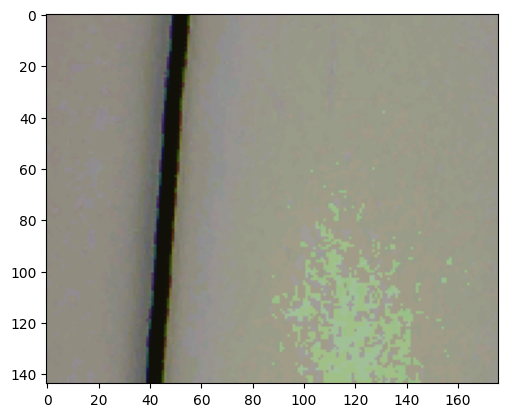

In [3]:
# Reformat the bytes into an image
raw_bytes = np.array(HEXADECIMAL_BYTES, dtype=np.uint16)
raw_bytes = raw_bytes.byteswap()  # Fix byte order from Arduino output
image = np.zeros((len(raw_bytes),3), dtype=int)

# Loop through all of the pixels and form the image
for i in range(len(raw_bytes)):
    #Read 16-bit pixel
    pixel = int(raw_bytes[i])

    #Convert RGB565 to RGB 24-bit
    r = ((pixel >> 11) & 0x1f) << 3;
    g = ((pixel >> 5) & 0x3f) << 2;
    b = ((pixel >> 0) & 0x1f) << 3;
    image[i] = [r,g,b]

image = np.reshape(image,(144, 176,3)) #QCIF resolution

# Show the image
plt.imshow(image)
plt.show()